# 03_regression

This notebook demonstrates the empirical line calibration (ELC) of the H20T image temperatures against the PT100 ground references, using ordinary least-squares linear regression.

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
from modules.utils import aggregate_calibration_data

Let's load and aggregate the calibration dataframe built for the flight campaign on 7 Aug 2025. Aggregation collapses the many frames captured within each reference minute into a single point per TCP, which avoids the oversampling that would otherwise bias the fit towards the plates with more detections.

In [3]:
DATE = "20250807"

OUTPUT_DIR = "results/03_regression"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_parquet(f"data/ancillary/{DATE}_calibration_df.parquet")
df_agg = aggregate_calibration_data(df)
df_agg

,tcp_name,timestamp,pt100_temperature,img_temperature,n_images,temperature_diff
0,tcp1_plate,2025-08-07 13:58:00,53.35,59.549992,2,-6.199992
1,tcp1_plate,2025-08-07 14:00:00,54.92,60.716663,6,-5.796663
2,tcp3_plate,2025-08-07 13:57:00,42.60,43.037498,4,-0.437498
3,tcp3_water,2025-08-07 13:57:00,16.60,9.649994,4,6.950006
4,tcp3_water,2025-08-07 13:59:00,16.50,9.850006,2,6.649994
5,tcp5_plate,2025-08-07 13:51:00,52.48,54.621429,7,-2.141429
6,tcp5_plate,2025-08-07 13:53:00,53.75,52.583340,3,1.166660
7,tcp5_water,2025-08-07 13:51:00,16.66,10.107141,7,6.552859
8,tcp5_water,2025-08-07 13:53:00,16.36,10.866658,3,5.493342
9,tcp6_plate,2025-08-07 13:49:00,55.70,54.500000,2,1.200000


Fit the empirical line calibration: an OLS regression of the PT100 reference temperature on the image temperature (`y = ax + b`). The fitted line maps the sensor's brightness temperature onto the reference temperature and is later used to correct the imagery. It is shown here first on the raw, disaggregated detections.

Regression coefficients (y = a*x + b):
Gain (a)   = 0.8112
Offset (b) = 8.631
R-squared before: 0.92
R-squared after: 0.98


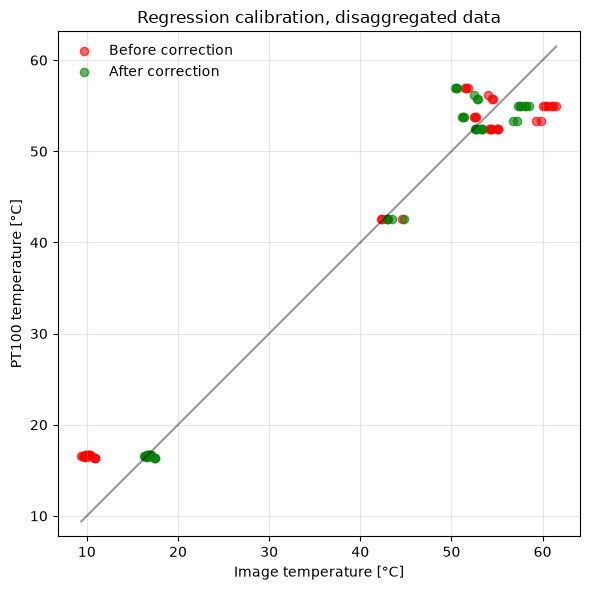

In [ ]:
X = df.img_temperature.values.reshape(-1, 1)
y = df.pt100_temperature.values

model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_
n = len(y)
p = X.shape[1]

print("Regression coefficients (y = a*x + b):")
print(f"Gain (a) = {a:.4f}")
print(f"Offset (b) = {b:.3f}")

df["predicted_temperature"] = model.predict(df.img_temperature.values.reshape(-1, 1))

r2_bef = f"{r2_score(y, X):.2f}"
print("R-squared before:", r2_bef)
r2 = f"{r2_score(y, df['predicted_temperature'].values):.2f}"
print("R-squared after:", r2)
plt.figure(figsize=(6, 6))
plt.scatter(df['img_temperature'], df['pt100_temperature'], color="red", alpha=0.6, label='Before correction')
plt.scatter(df['predicted_temperature'], df['pt100_temperature'], color='green', alpha=0.6, label='After correction')

lims = [
    np.min([df['pt100_temperature'].min(), df['predicted_temperature'].min(), df['img_temperature'].min()]),
    np.max([df['pt100_temperature'].max(), df['predicted_temperature'].max(), df['img_temperature'].max()])
]
plt.plot(lims, lims, 'k-', alpha=0.4)
plt.legend(frameon=False)
plt.xlabel('Image temperature [°C]')
plt.ylabel('PT100 temperature [°C]')
plt.title('Regression calibration, disaggregated data')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()

Now the same fit, but on the minute-aggregated points (one value per TCP per reference minute). This is the version used for the calibration, since it avoids oversampling the frames captured only seconds apart.

Regression coefficients (y = a*x + b):
Gain (a)   = 0.8298
Offset (b) = 8.422
R-squared before: 0.93
R-squared after: 0.98


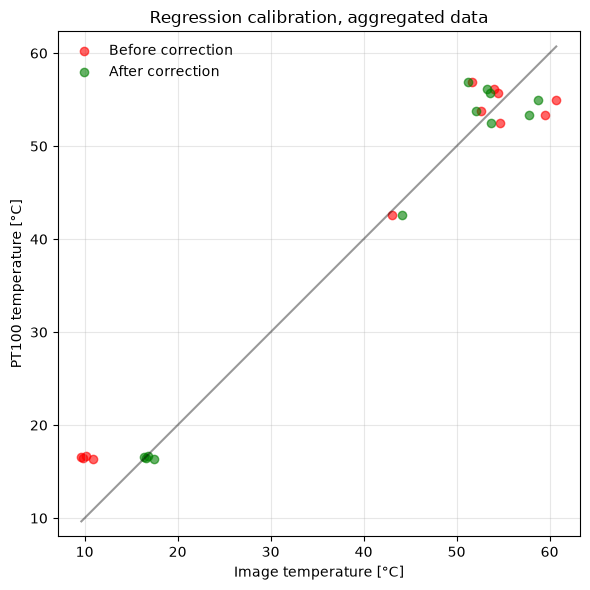

In [ ]:
X = df_agg.img_temperature.values.reshape(-1, 1)
y = df_agg.pt100_temperature.values

model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_
n = len(y)
p = X.shape[1]

print("Regression coefficients (y = a*x + b):")
print(f"Gain (a) = {a:.4f}")
print(f"Offset (b) = {b:.3f}")

df_agg["predicted_temperature"] = model.predict(df_agg.img_temperature.values.reshape(-1, 1))

r2_bef = f"{r2_score(y, X):.2f}"
print("R-squared before:", r2_bef)
r2 = f"{r2_score(y, df_agg['predicted_temperature'].values):.2f}"
print("R-squared after:", r2)


plt.figure(figsize=(6, 6))
plt.scatter(df_agg['img_temperature'], df_agg['pt100_temperature'], color="red", alpha=0.6, label='Before correction')
plt.scatter(df_agg['predicted_temperature'], df_agg['pt100_temperature'], color='green', alpha=0.6, label='After correction')

lims = [
    np.min([df_agg['pt100_temperature'].min(), df_agg['predicted_temperature'].min(), df_agg['img_temperature'].min()]),
    np.max([df_agg['pt100_temperature'].max(), df_agg['predicted_temperature'].max(), df_agg['img_temperature'].max()])
]
plt.plot(lims, lims, 'k-', alpha=0.4)
plt.legend(frameon=False)
plt.xlabel('Image temperature [°C]')
plt.ylabel('PT100 temperature [°C]')
plt.title('Regression calibration, aggregated data')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()

How were the residuals affected by the calibration? We plot the ref-img difference before correction against the ref-prediction residual after correction, over the course of the flight.

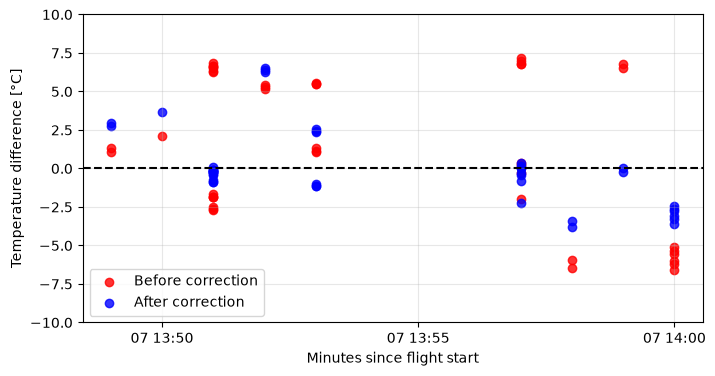

In [6]:
df["residual"] = df["pt100_temperature"] - df["predicted_temperature"]

plt.figure(figsize=(8,4))
plt.scatter(df["timestamp"], df["temperature_diff"], color="red", alpha=0.8, label="Before correction")
plt.scatter(df["timestamp"], df["residual"], color="blue", alpha=0.8, label="After correction")

plt.xlabel("Minutes since flight start")
plt.ylabel("Temperature difference [°C]")
plt.legend()
plt.ylim(-10,10)
plt.grid(alpha=0.3)
plt.axhline(0, color="k", linestyle="--")

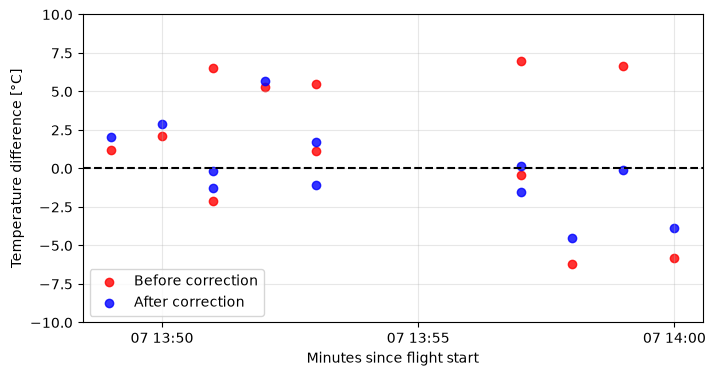

In [7]:
df_agg["residual"] = df_agg["pt100_temperature"] - df_agg["predicted_temperature"]

plt.figure(figsize=(8,4))
plt.scatter(df_agg["timestamp"], df_agg["temperature_diff"], color="red", alpha=0.8, label="Before correction")
plt.scatter(df_agg["timestamp"], df_agg["residual"], color="blue", alpha=0.8, label="After correction")

plt.xlabel("Minutes since flight start")
plt.ylabel("Temperature difference [°C]")
plt.legend()
plt.ylim(-10,10)
plt.grid(alpha=0.3)
plt.axhline(0, color="k", linestyle="--")

Did the calibration improve the agreement? We compare the RMSE of the img/ref difference before and after applying the fitted regression.

In [8]:
residuals = df.pt100_temperature.values - df.predicted_temperature.values
before_rmse = np.sqrt(np.mean(df["temperature_diff"]**2))
after_rmse  = np.sqrt(np.mean(residuals**2))
print(f"Before RMSE = {before_rmse:.3f} °C")
print(f"After RMSE = {after_rmse:.3f} °C")
print(f"Improvement = {(1 - after_rmse/before_rmse)*100:.1f}%")

Before RMSE = 4.969 °C
After RMSE = 2.446 °C
Improvement = 50.8%


In [9]:
residuals = df_agg.pt100_temperature.values - df_agg.predicted_temperature.values
before_rmse = np.sqrt(np.mean(df_agg["temperature_diff"]**2))
after_rmse  = np.sqrt(np.mean(residuals**2))
print(f"Before RMSE = {before_rmse:.3f} °C")
print(f"After RMSE = {after_rmse:.3f} °C")
print(f"Improvement = {(1 - after_rmse/before_rmse)*100:.1f}%")

Before RMSE = 4.811 °C
After RMSE = 2.707 °C
Improvement = 43.7%


## Leave one out CV

Because only a handful of reference targets are available per flight, we validate the fit by leave-one-out cross-validation (LOO-CV): each TCP is withheld in turn, the line is refitted on the remaining references, and the held-out target is predicted from that fit. This tests how well the calibration generalises to a reference it was not trained on.

In [10]:
all_tcp_names = df.tcp_name.unique()
results=[]
for tcp in all_tcp_names:
    mask = df.tcp_name == tcp
    left_out_tcp = df[mask]
    X_df = df[~mask]
    X = X_df.img_temperature.values.reshape(-1,1)
    y = X_df.pt100_temperature.values
    model = LinearRegression()
    model.fit(X, y)
    left_out_tcp["predicted_temperature"] = model.predict(left_out_tcp.img_temperature.values.reshape(-1,1))
    
    errors = left_out_tcp["predicted_temperature"] - left_out_tcp["pt100_temperature"]
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    bias = np.mean(errors)
    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((left_out_tcp["pt100_temperature"] - left_out_tcp["pt100_temperature"].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    results.append({"tcp": tcp,
                    "n": len(left_out_tcp["pt100_temperature"]),
                    "bias": round(bias, 3),
                    "MAE": round(mae, 3),
                    "RMSE": round(rmse, 3),
                    "a": model.coef_[0],
                    "b": model.intercept_})

df_loo = pd.DataFrame(results).set_index("tcp")
print(df_loo.to_string())

print(f"Mean bias: {df_loo['bias'].mean():.3f} °C")
print(f"Mean MAE: {df_loo['MAE'].mean():.3f} °C")
print(f"Mean RMSE: {df_loo['RMSE'].mean():.3f} °C")

             n   bias    MAE   RMSE         a         b
tcp                                                    
tcp1_plate   8  5.003  5.003  5.024  0.854793  7.879854
tcp3_plate   4  1.042  1.042  1.289  0.812322  8.681986
tcp3_water   6 -0.086  0.156  0.199  0.811899  8.591576
tcp5_plate  10 -0.629  1.005  1.502  0.806945  8.649002
tcp5_water  10  1.112  1.112  1.193  0.796226  9.452694
tcp6_plate   6 -5.968  5.968  6.186  0.785787  8.783714
Mean bias: 0.079 °C
Mean MAE: 2.381 °C
Mean RMSE: 2.565 °C


In [11]:
all_tcp_names = df_agg.tcp_name.unique()
results=[]
for tcp in all_tcp_names:
    mask = df_agg.tcp_name == tcp
    left_out_tcp = df_agg[mask]
    X_df_agg = df_agg[~mask]
    X = X_df_agg.img_temperature.values.reshape(-1,1)
    y = X_df_agg.pt100_temperature.values
    model = LinearRegression()
    model.fit(X, y)
    left_out_tcp["predicted_temperature"] = model.predict(left_out_tcp.img_temperature.values.reshape(-1,1))
    
    errors = left_out_tcp["predicted_temperature"] - left_out_tcp["pt100_temperature"]
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    bias = np.mean(errors)
    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((left_out_tcp["pt100_temperature"] - left_out_tcp["pt100_temperature"].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    results.append({"tcp": tcp,
                    "n": len(left_out_tcp["pt100_temperature"]),
                    "bias": round(bias, 3),
                    "MAE": round(mae, 3),
                    "RMSE": round(rmse, 3),
                    "a": model.coef_[0],
                    "b": model.intercept_})

df_agg_loo = pd.DataFrame(results).set_index("tcp")
print(df_agg_loo.to_string())

print(f"Mean bias: {df_agg_loo['bias'].mean():+.3f} °C")
print(f"Mean MAE: {df_agg_loo['MAE'].mean():.3f} °C")
print(f"Mean RMSE: {df_agg_loo['RMSE'].mean():.3f} °C")

            n   bias    MAE   RMSE         a         b
tcp                                                   
tcp1_plate  2  6.252  6.252  6.257  0.878939  7.533005
tcp3_plate  1  1.677  1.677  1.677  0.830961  8.514511
tcp3_water  2 -0.076  0.133  0.153  0.830615  8.375713
tcp5_plate  2 -0.275  1.480  1.505  0.828847  8.411930
tcp5_water  2  1.174  1.174  1.261  0.817089  9.115028
tcp6_plate  3 -5.532  5.532  5.728  0.786592  8.733706
Mean bias: +0.537 °C
Mean MAE: 2.708 °C
Mean RMSE: 2.763 °C


We can save the model fitted on the aggregated data. If anything fails, a pre-computed model is provided in the `results/03_regression` directory.

In [12]:
joblib.dump(model, f"results/03_regression/model_{DATE}.pkl")

['results/03_regression/model_20250807.pkl']

Generate the models for every flight (no need to run this cell). It fits and saves one model per flight date and prints the per-flight calibration and LOO metrics reported in the thesis.

# Generate all models

In [14]:
DATES = ['20250622', '20250807', '20250813', '20250814']

records = []

for date in DATES:
    pq = f"data/ancillary/{date}_calibration_df.parquet"
    d = pd.read_parquet(pq)
       
    raw_err = d['temperature_diff']
    bef_bias = raw_err.mean()
    bef_rmse = np.sqrt(np.mean(raw_err**2))
    bef_mae = raw_err.abs().mean()
    bef_var = raw_err.var(ddof=1)

    agg = (d.groupby('tcp_name')#d.rename(columns={"img_temperature":"img", "pt100_temperature":"ref"})#
            .agg(img=('img_temperature', 'median'),
                 ref=('pt100_temperature', 'median'))
            .reset_index())
    plates = agg[agg['tcp_name'].str.endswith('_plate')]
    water  = agg[agg['tcp_name'].str.endswith('_water')]

    X_fit = agg[['img']].values
    y_fit = agg['ref'].values
    model = LinearRegression().fit(X_fit, y_fit)
    slope = model.coef_[0]
    intercept = model.intercept_
    joblib.dump(model, f"results/03_regression/model_{date}.pkl")

    d = d.copy()
    d['pred'] = model.predict(d[['img_temperature']].values)
    aft_err = d['pt100_temperature'] - d['pred']
    aft_rmse = np.sqrt(np.mean(aft_err**2))
    aft_mae = aft_err.abs().mean()
    aft_var = aft_err.var(ddof=1)
    mae_imp = (1 - aft_mae / bef_mae) * 100
    rmse_imp = (1 - aft_rmse / bef_rmse) * 100

    loo_residuals = []
    for tcp in agg['tcp_name']:
        train = agg[agg['tcp_name'] != tcp]
        hold = agg[agg['tcp_name'] == tcp]
        if len(train) < 2:
            continue
        m_loo = LinearRegression().fit(train[['img']].values, train['ref'].values)
        pred_h = m_loo.predict(hold[['img']].values)
        loo_residuals.extend((hold['ref'].values - pred_h).tolist())
    loo_residuals = np.array(loo_residuals)
    loo_mae = np.mean(np.abs(loo_residuals)) if len(loo_residuals) else np.nan
    loo_rmse = np.sqrt(np.mean(loo_residuals ** 2)) if len(loo_residuals) else np.nan

    records.append({
        "date":date, "n_tcps":len(agg), "n_plates":len(plates), "n_water":len(water),
        "n_rows":len(d), "bef_bias":bef_bias, "bef_rmse":bef_rmse, "bef_mae":bef_mae, "bef_var":bef_var,
        "slope":slope, "intercept":intercept, "aft_rmse":aft_rmse, "aft_mae":aft_mae, "aft_var":aft_var, 
        "mae_imp":mae_imp, "rmse_imp":rmse_imp, "loo_mae":loo_mae, "loo_rmse":loo_rmse, "df":d, "agg":agg})

res = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in records])

print("="*98)
print(f"{'Date':<10} {'P+W':>4} {'Bias':>8} {'Bef.RMSE':>9} {'Aft.RMSE':>9} "
      f"{'MAE Imp':>7} {'RMSE Imp%':>7} {'slope':>7} {'intercept':>10} {'LOO-MAE':>8} {'LOO-RMSE':>8}")
print("-"*98)
for _, r in res.iterrows():
    print(f"{r.date:<10} {r.n_tcps:>4.0f}  {r.bef_bias:>+7.2f}°C {r.bef_rmse:>8.3f} "
          f"{r.aft_rmse:>9.3f} {r.mae_imp:>7.1f} {r.rmse_imp:>7.1f} "
          f"{r.slope:>7.4f} {r.intercept:>10.3f} {r.loo_mae:>8.3f} {r.loo_rmse:>8.3f}")
print("="*98)
print(f"Bias range: {res.bef_bias.min():+.2f} – {res.bef_bias.max():+.2f} °C")
print(f"Slope range: {res.slope.min():.4f} – {res.slope.max():.4f}")
print(f"Mean LOO-MAE: {res.loo_mae.mean():.3f} °C")
print(f"Mean LOO-RMSE: {res.loo_rmse.mean():.3f} °C")


Date        P+W     Bias  Bef.RMSE  Aft.RMSE MAE Imp RMSE Imp%   slope  intercept  LOO-MAE LOO-RMSE
--------------------------------------------------------------------------------------------------
20250622      6    +2.77°C    3.249     1.581    57.1    51.3  1.0343      1.166    1.281    1.612
20250807      6    +1.44°C    4.969     2.458    60.0    50.5  0.8164      8.645    2.214    3.238
20250813      7    +5.95°C    6.365     1.905    75.2    70.1  0.9433      8.390    2.884    3.417
20250814      6    +2.64°C    3.031     1.515    58.6    50.0  1.0183      2.131    1.564    1.993
Bias range: +1.44 – +5.95 °C
Slope range: 0.8164 – 1.0343
Mean LOO-MAE: 1.986 °C
Mean LOO-RMSE: 2.565 °C
